## Customer Churn Prediction

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as mp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
SEED = 42

In [2]:
url='https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df=pd.read_csv(url)
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# converting TotalCharges to numeric and see what breaks
pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()

11

In [5]:
problem_rows = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()]
problem_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [6]:
df_clean = df.copy()

# Convert to numeric, coercing errors to NaN
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Fill the NaN (new customers) with 0 — they haven't been billed yet
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

print(f'Remaining nulls in TotalCharges: {df_clean["TotalCharges"].isnull().sum()}')
print(f'Data type now: {df_clean["TotalCharges"].dtype}')

Remaining nulls in TotalCharges: 0
Data type now: float64


In [7]:
df_clean['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
Npct=5174/7043*100
Ypct=1869/7043*100
print('No Percentage:', Npct)
print('Yes Percentage:', Ypct)

No Percentage: 73.4630129206304
Yes Percentage: 26.536987079369588


## Pre-EDA Hypothesis

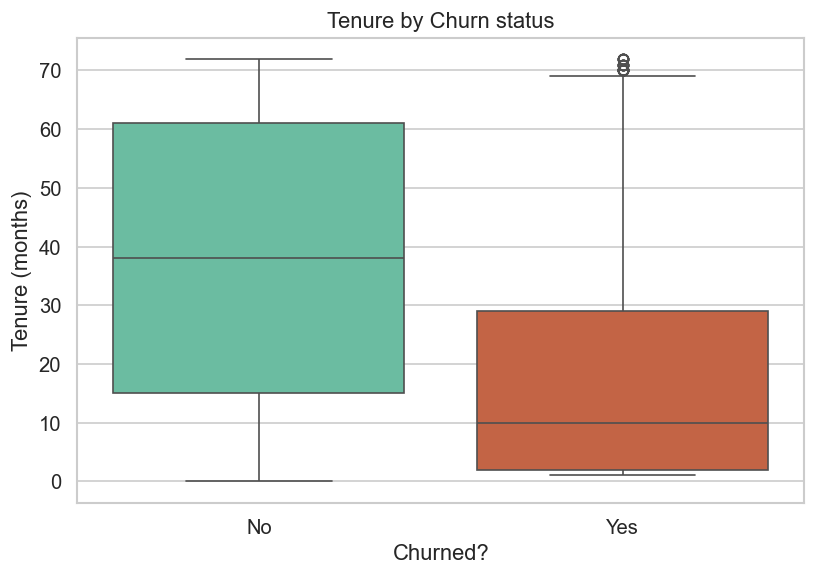

In [10]:
# I. Does Tenure affect churn?
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_clean, x='Churn', y='tenure', 
            palette=['#5DCAA5', '#D85A30'], ax=ax)
ax.set_title('Tenure by Churn status')
ax.set_xlabel('Churned?')
ax.set_ylabel('Tenure (months)')
plt.tight_layout()
plt.show()

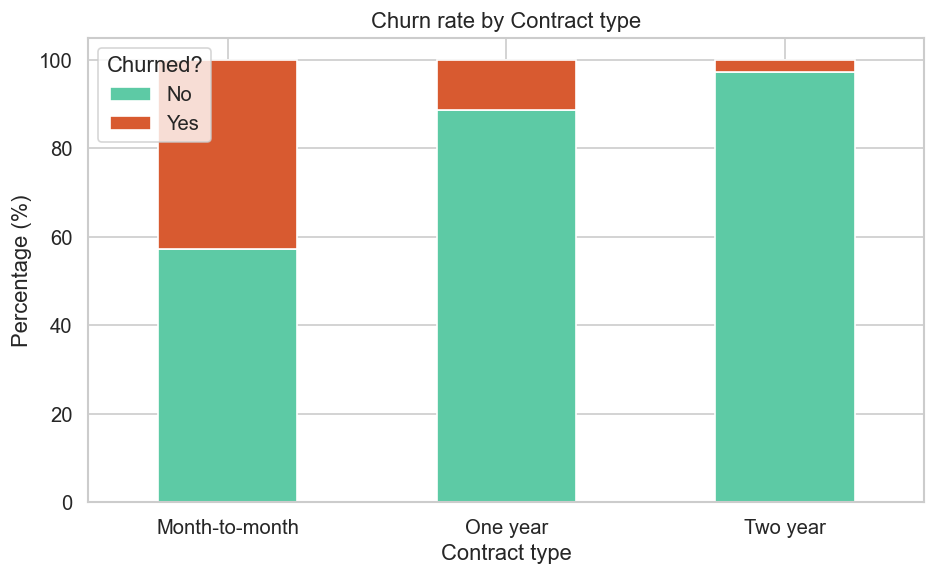

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


In [11]:
# II. Does Contact type affect churn?
contract_churn = pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 5))
contract_churn.plot(kind='bar', stacked=True, 
                     color=['#5DCAA5', '#D85A30'], ax=ax)
ax.set_title('Churn rate by Contract type')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Contract type')
ax.legend(title='Churned?', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(contract_churn.round(1))

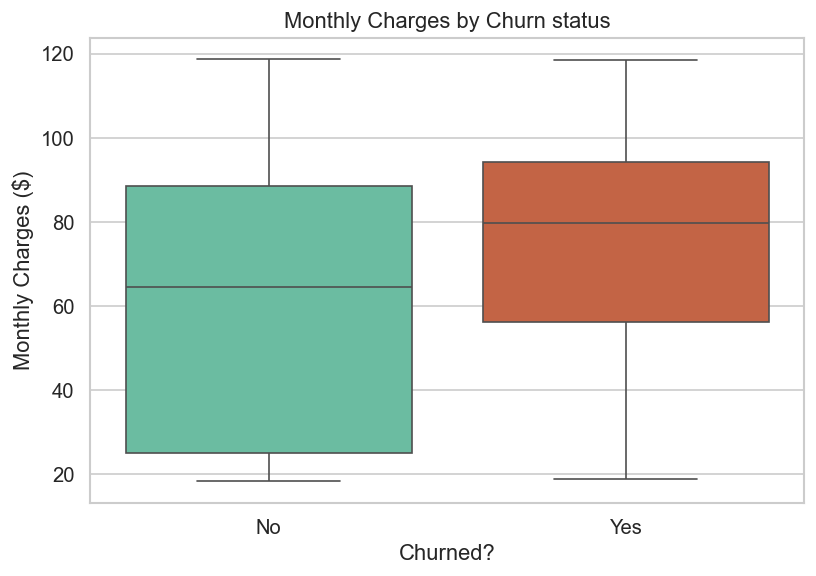

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64


In [12]:
#III. Do monthly charges affect churn?
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges',
            palette=['#5DCAA5', '#D85A30'], ax=ax)
ax.set_title('Monthly Charges by Churn status')
ax.set_xlabel('Churned?')
ax.set_ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

print(df_clean.groupby('Churn')['MonthlyCharges'].median())

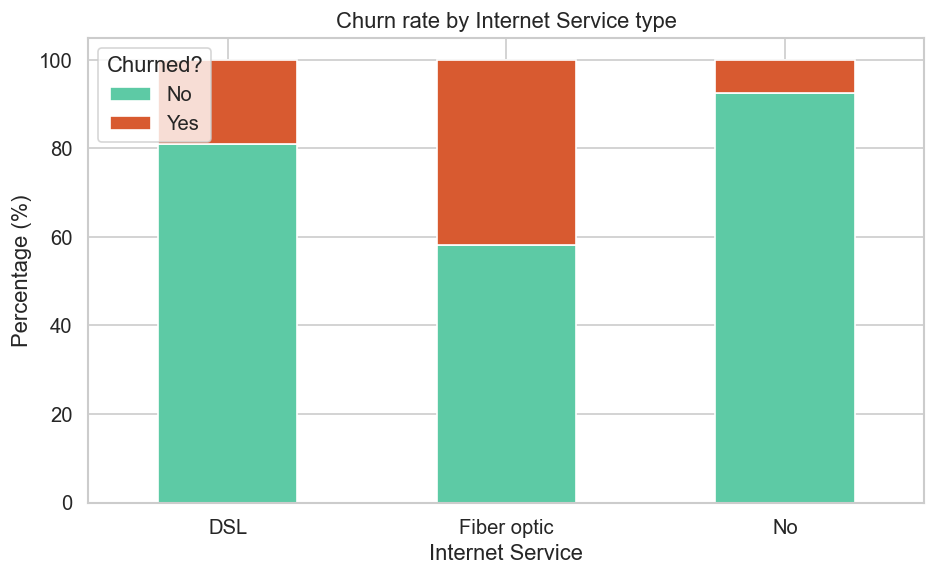

Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.1  41.9
No               92.6   7.4


In [13]:
internet_churn = pd.crosstab(df_clean['InternetService'], 
                              df_clean['Churn'], 
                              normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 5))
internet_churn.plot(kind='bar', stacked=True,
                    color=['#5DCAA5', '#D85A30'], ax=ax)
ax.set_title('Churn rate by Internet Service type')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Internet Service')
ax.legend(title='Churned?', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(internet_churn.round(1))

In [14]:
df_clean = df_clean.drop(columns=['customerID'])
print(f'Columns remaining: {df_clean.shape[1]}')

Columns remaining: 20


In [15]:
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {len(cat_cols)}')
print(cat_cols)

Categorical columns to encode: 16
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [16]:
# Binary columns — simple Yes/No or Male/Female mapping
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 
               'PaperlessBilling']

binary_map = {'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0}

for col in binary_cols:
    df_clean[col] = df_clean[col].map(binary_map)

# Encode target variable separately
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

print('Binary encoding done.')
print(df_clean[binary_cols + ['Churn']].head())

Binary encoding done.
   gender  Partner  Dependents  PhoneService  PaperlessBilling  Churn
0       1        1           0             0                 1      0
1       0        0           0             1                 0      0
2       0        0           0             1                 1      1
3       0        0           0             0                 0      0
4       1        0           0             1                 1      1


In [17]:
contract_map = {
    'Month-to-month': 0,
    'One year'      : 1,
    'Two year'      : 2
}

df_clean['Contract'] = df_clean['Contract'].map(contract_map)

print('Contract encoding done.')
print(df_clean['Contract'].value_counts())

Contract encoding done.
Contract
0    3875
2    1695
1    1473
Name: count, dtype: int64


In [18]:
ohe_cols = ['InternetService', 'MultipleLines', 'OnlineSecurity', 
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'PaymentMethod']
#one hot encoding
df_clean = pd.get_dummies(df_clean, columns=ohe_cols, drop_first=True)

print(f'Shape after one-hot encoding: {df_clean.shape}')
print(f'New columns added: {df_clean.shape[1] - 20}')
df_clean.head(2)

Shape after one-hot encoding: (7043, 30)
New columns added: 10


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0,34,1,1,0,56.95,1889.50,...,True,False,False,False,False,False,False,False,False,True


In [19]:
print('Any nulls remaining:', df_clean.isnull().sum().sum())
print('Data types:')
print(df_clean.dtypes.value_counts())
print('\nFirst 2 rows:')
df_clean.head(2)

Any nulls remaining: 0
Data types:
bool       19
int64       9
float64     2
Name: count, dtype: int64

First 2 rows:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0,34,1,1,0,56.95,1889.50,...,True,False,False,False,False,False,False,False,False,True


In [20]:
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print('Dtypes after conversion:')
print(df_clean.dtypes.value_counts())

Dtypes after conversion:
int32      19
int64       9
float64     2
Name: count, dtype: int64


In [21]:
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

print(f'Features shape: {X.shape}')
print(f'Target shape  : {y.shape}')
print(f'Churn rate    : {y.mean()*100:.1f}%')

Features shape: (7043, 29)
Target shape  : (7043,)
Churn rate    : 26.5%


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Training set : {X_train.shape[0]} rows')
print(f'Test set     : {X_test.shape[0]} rows')
print(f'Train churn rate: {y_train.mean()*100:.1f}%')
print(f'Test churn rate : {y_test.mean()*100:.1f}%')

Training set : 5634 rows
Test set     : 1409 rows
Train churn rate: 26.5%
Test churn rate : 26.5%


In [23]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# SMOTE
smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f'Before SMOTE: {dict(y_train.value_counts())}')
print(f'After  SMOTE: {dict(zip(*__import__("numpy").unique(y_train_res, return_counts=True)))}')
print(f'Training set grew from {len(y_train)} → {len(y_train_res)} rows')

Before SMOTE: {0: 4139, 1: 1495}
After  SMOTE: {0: 4139, 1: 4139}
Training set grew from 5634 → 8278 rows


In [24]:
# Training the models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=6, random_state=SEED),
    'XGBoost'            : xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                              eval_metric='logloss', random_state=SEED, verbosity=0)
}

trained = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    trained[name] = model
    print(f'  {name} trained')

  Logistic Regression trained
  Random Forest trained
  XGBoost trained


In [49]:
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)

# Metrics table
results = []
for name, model in trained.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 3),
        'Recall'   : round(recall_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'F1-Score' : round(f1_score(y_test, y_pred), 3),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 3)
    })

results_df = pd.DataFrame(results).set_index('Model')
print('=== Model Performance on Test Set ===')
results_df

=== Model Performance on Test Set ===


,Accuracy,Recall,Precision,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.738,0.799,0.504,0.618,0.841
Random Forest,0.750,0.781,0.520,0.624,0.842
XGBoost,0.776,0.671,0.567,0.614,0.842


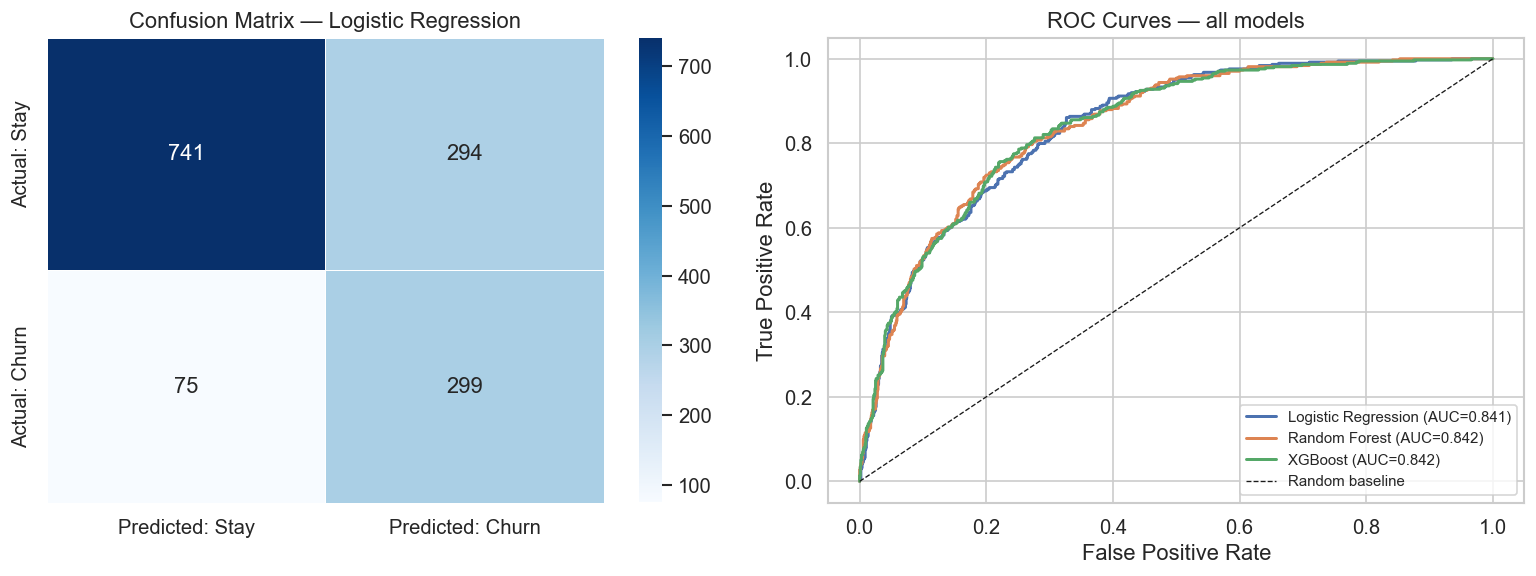

              precision    recall  f1-score   support

        Stay       0.91      0.72      0.80      1035
       Churn       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [53]:
# Best model based on Recall
best_model  = trained['Logistic Regression']
y_pred_best = best_model.predict(X_test_scaled)

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'],
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix — Logistic Regression')

# ROC curves — fixed version
colors = ['#378ADD', '#1D9E75', '#D85A30']
for (name, model), color in zip(trained.items(), colors):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = __import__('sklearn.metrics', fromlist=['roc_curve']).roc_curve(y_test, y_prob)
    auc = round(roc_auc_score(y_test, y_prob), 3)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc})', lw=1.8)

axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random baseline')
axes[1].set_title('ROC Curves — all models')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_best,
      target_names=['Stay', 'Churn']))

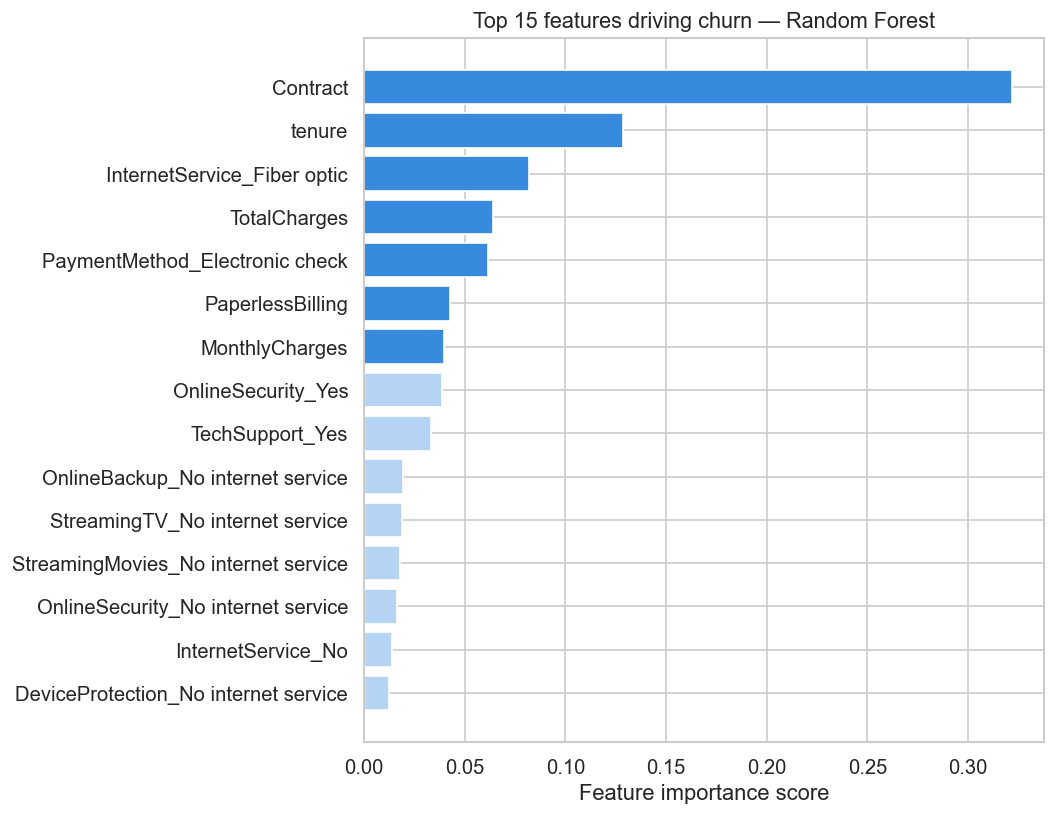

Top 5 most important features:
Contract                          0.321860
tenure                            0.128492
InternetService_Fiber optic       0.082108
TotalCharges                      0.063946
PaymentMethod_Electronic check    0.061710
dtype: float64


In [59]:
# Random Forest built-in feature importance
importances = pd.Series(
    trained['Random Forest'].feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(15)  # top 15 features

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(importances.index, importances.values,
               color=['#378ADD' if v > importances.median() 
                      else '#B5D4F4' for v in importances.values])
ax.set_title('Top 15 features driving churn — Random Forest', fontsize=13)
ax.set_xlabel('Feature importance score')
plt.tight_layout()
plt.savefig('feature_importance_churn.png', bbox_inches='tight', dpi=150)
plt.show()

# top 5
print('Top 5 most important features:')
print(importances.tail(5).sort_values(ascending=False))

## Business Insights & Recommendations

### Pre-EDA Hypothesis vs Reality
Before seeing any data, I hypothesised that tenure, contract type, 
and charges would be the primary churn drivers. The model confirmed 
all three — with contract type emerging as the single strongest 
predictor (importance score 0.32, 2.5x higher than the next feature).

### Key findings

**1. Contract type is the dominant churn driver**
Month-to-month customers churn at 42.7% vs just 2.8% for two-year 
contracts. Over half the customer base (55%) is on month-to-month 
plans — representing the single largest retention risk in the business.

**Recommendation:** Introduce incentives to migrate month-to-month 
customers to annual contracts — discounted first year, loyalty rewards, 
or bundled service deals. Even converting 20% of month-to-month 
customers to annual contracts would significantly reduce overall churn.

**2. New customers are the highest risk group**
Churned customers had a median tenure of just 10 months vs 38 months 
for retained customers. The first year is the critical retention window.

**Recommendation:** Implement a dedicated onboarding programme for 
new customers — proactive check-in calls at 30, 60, and 90 days, 
fast issue resolution, and first-year loyalty discounts.

**3. Fiber optic customers are churning at alarming rates (41.9%)**
Despite being the premium, highest-paying service, fiber optic 
customers are the most likely to leave. This suggests a value 
perception gap — customers are paying premium prices but not 
feeling they receive premium value.

**Recommendation:** Audit fiber optic service quality — speeds, 
reliability, and support response times. Consider a satisfaction 
survey specifically targeting fiber optic customers to identify 
specific pain points.

**4. Electronic check payment method signals churn risk**
Customers paying by electronic check churn more than those on 
automatic payment methods. Manual payment customers actively 
see their bill each month, making them more price-sensitive.

**Recommendation:** Offer a small discount or reward for switching 
to automatic payment — this reduces both churn risk and payment 
processing costs simultaneously.

### Model deployment recommendation
Deploy Logistic Regression (selected for highest Recall of 0.799) 
as a weekly batch scoring tool. Every Monday, score all active 
customers and flag the top 20% highest churn probability for 
the retention team to contact that week. At 299 correctly 
identified churners per 1,409 customers scored, the model 
provides actionable, reliable targeting for retention efforts.

## Ethical Considerations

### 1. Fairness and demographic bias
This model uses gender and senior citizen status as features. 
Before deployment, the model should be audited for discriminatory 
patterns — for example, does it flag senior citizens for churn 
at disproportionate rates regardless of their actual behaviour? 
Retention offers should be based on churn risk, not demographic 
characteristics.

### 2. Retention offer fairness
If the model drives targeted retention offers (discounts, upgrades), 
customers not flagged by the model receive no offer — even if they 
are also at risk. This creates a two-tier customer experience. 
The business should monitor whether certain customer segments 
are systematically excluded from retention benefits.

### 3. Data privacy
Customer behaviour data (payment history, service usage, billing) 
is sensitive. It must be stored securely, access-controlled, and 
handled in compliance with applicable data protection regulations. 
Customers should be informed if their data is used for predictive 
modelling.

### 4. Model transparency
Logistic Regression was selected as the final model partly because 
its predictions are more interpretable than black-box models. 
Retention agents acting on model predictions should understand 
what factors drove a customer's risk score — not just receive 
a binary "high risk" flag.

### 5. Model drift monitoring
Customer behaviour patterns change over time — new competitors, 
economic conditions, and product changes all shift what drives 
churn. The model should be retrained every 6 months and monitored 
for performance degradation between retraining cycles.